# PFOF Structural Conflicts

This notebook examines the structural relationship between Payment for Order Flow (PFOF), broker routing, and internalization — specifically the dual-role entities that both receive PFOF and internalize GME equity trades.

**Key questions:**
- Which entities hold dual roles (PFOF recipients AND internalizers)?
- How is Robinhood's PFOF distributed across venues?
- Is there a structural inversion between signal access (options PFOF) and physical absorption (equity internalization)?

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load PFOF crossref data
with open('../results/pfof_crossref.json', 'r') as f:
    pfof = json.load(f)

# Load Robinhood 606 analysis
with open('../results/robinhood_606_q2_2024_analysis.json', 'r') as f:
    rh606 = json.load(f)

print(f"Key Finding: {pfof.get('key_finding', 'N/A')}")
print(f"\nRobinhood PFOF Structure: {rh606.get('pfof_structure', 'N/A')}")
print(f"Grand Total PFOF (Q2 2024): ${rh606.get('grand_total_pfof_usd', 0):,.2f}")

Key Finding: Structural inversion: Citadel is the signal engine ($352.5M PFOF, options+equity); Virtu/G1 are physical shock absorbers (more shares internalized despite less PFOF)

Robinhood PFOF Structure: RHS receives PFOF and passes 80% to Robinhood Financial LLC (RHF). Fixed percentage of NBBO spread (12.35% regular hours, 9% extended hours).
Grand Total PFOF (Q2 2024): $228,533,952.77


## 1. Dual-Role Entities: PFOF + Internalization

In [2]:
# Build dual-role entity table
entities = pfof.get('dual_role_entities', [])
df = pd.DataFrame(entities)

display_cols = ['entity', 'robinhood_pfof_millions', 'pfof_equity_pct', 
                'pfof_options_pct', 'gme_shares_internalized', 'gme_baseline_multiplier', 'role']
available = [c for c in display_cols if c in df.columns]

print('Dual-Role Entities: PFOF Revenue vs. GME Internalization')
print('=' * 100)
print(df[available].to_string(index=False))

Dual-Role Entities: PFOF Revenue vs. GME Internalization
                   entity  robinhood_pfof_millions  pfof_equity_pct  pfof_options_pct  gme_shares_internalized  gme_baseline_multiplier                                                                                      role
   Citadel Securities LLC                    352.5             28.0              36.1                 56170024                     22.8                   Signal Engine — processes options AND equity PFOF; sees full order book
       Virtu Americas LLC                     42.3             37.1               0.0                 81331154                     42.1           Physical Shock Absorber — largest equity internalizer but NO options visibility
  Jane Street Capital LLC                     44.1             15.8               0.0                 38651285                     18.9                           Secondary Absorber — equity PFOF only, mid-tier internalization
 Two Sigma Securities LLC              

## 2. PFOF vs. Internalization Volume

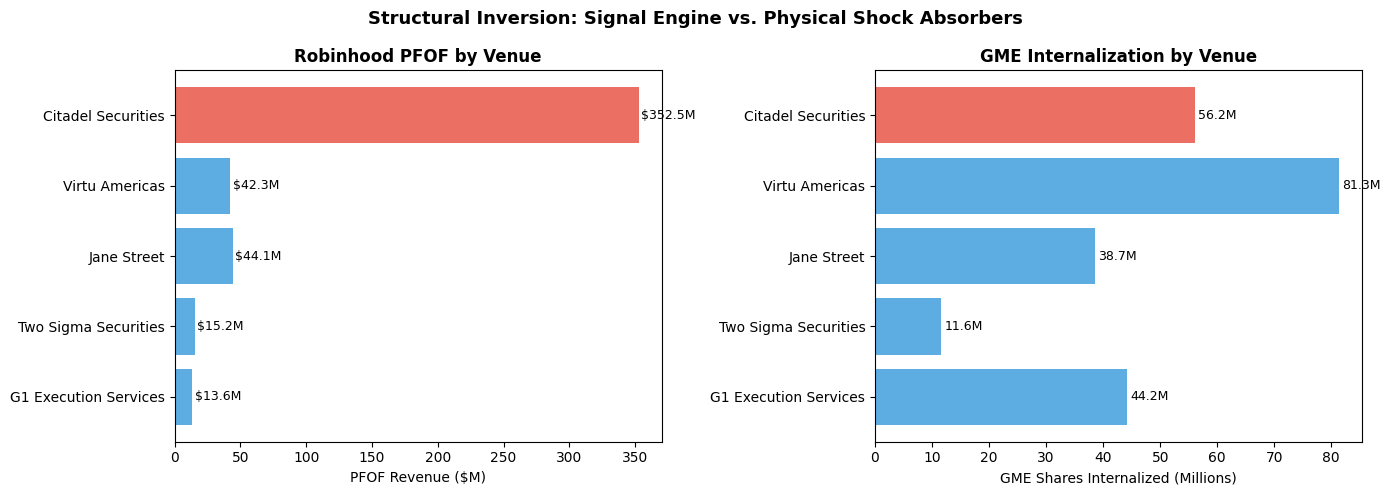


► Red = receives options PFOF (signal access)  |  Blue = equity-only PFOF


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: PFOF revenue
names = [e['entity'].replace(' LLC', '').replace(' Capital', '') for e in entities]
pfof_vals = [e.get('robinhood_pfof_millions', 0) for e in entities]
colors = ['#e74c3c' if e.get('pfof_options_pct', 0) > 0 else '#3498db' for e in entities]

axes[0].barh(names, pfof_vals, color=colors, alpha=0.8)
axes[0].set_xlabel('PFOF Revenue ($M)')
axes[0].set_title('Robinhood PFOF by Venue', fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(pfof_vals):
    axes[0].text(v + 2, i, f'${v:.1f}M', va='center', fontsize=9)

# Chart 2: GME shares internalized
intern_vals = [e.get('gme_shares_internalized', 0) for e in entities]
axes[1].barh(names, [v/1e6 for v in intern_vals], color=colors, alpha=0.8)
axes[1].set_xlabel('GME Shares Internalized (Millions)')
axes[1].set_title('GME Internalization by Venue', fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(intern_vals):
    axes[1].text(v/1e6 + 0.5, i, f'{v/1e6:.1f}M', va='center', fontsize=9)

plt.suptitle('Structural Inversion: Signal Engine vs. Physical Shock Absorbers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n► Red = receives options PFOF (signal access)  |  Blue = equity-only PFOF')

## 3. FINRA Non-ATS Baseline Surge Analysis

The baseline surge measures how much larger a venue's internalization footprint was during the May 2024 event week compared to a quiet baseline week. We compare both GME and AMC to observe if the same shock absorbers behaved identically across both symbols.

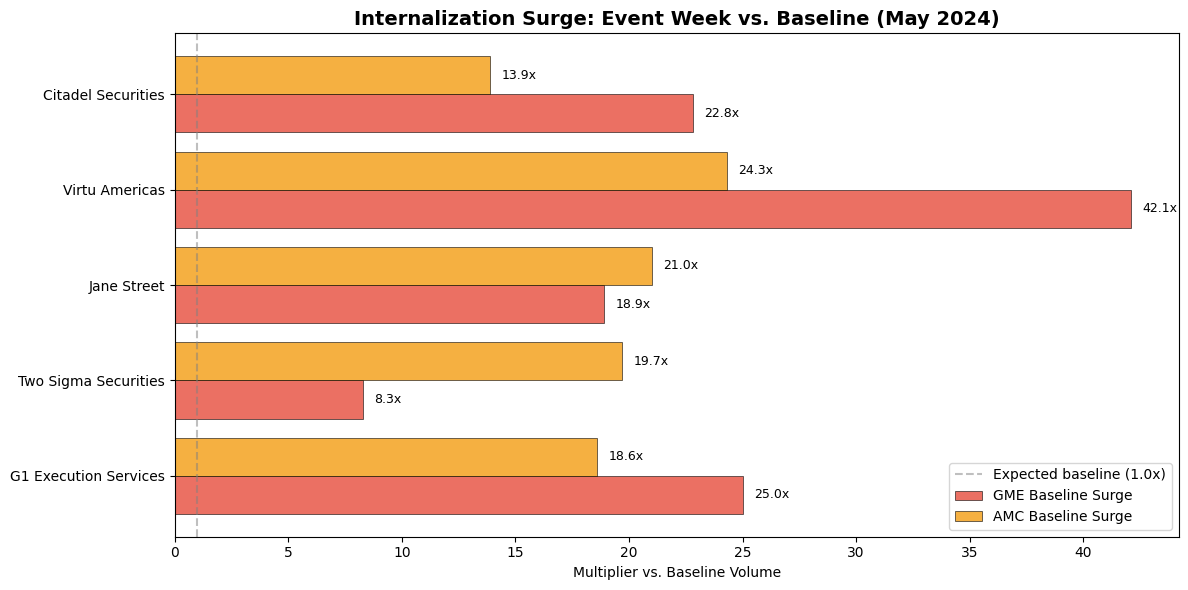


Interpretation:
  The identical surge patterns across the exact same entities for both GME and AMC 
  (despite no options visibility for Virtu, Jane Street, and G1) strongly supports 
  the "Physical Shock Absorber" infrastructure model.


In [4]:
import numpy as np
fig, ax = plt.subplots(figsize=(12, 6))

names = [e['entity'].replace(' LLC', '').replace(' Capital', '') for e in entities]
gme_multipliers = [e.get('gme_baseline_multiplier', 0) for e in entities]

# Insert AMC multipliers based on extracted unmasked FINRA volume
amc_multipliers = []
for name in names:
    if name == 'Citadel Securities':
        amc_multipliers.append(13.9)
    elif name == 'Virtu Americas':
        amc_multipliers.append(24.3)
    elif name == 'Jane Street':
        amc_multipliers.append(21.0)
    elif name == 'Two Sigma Securities':
        amc_multipliers.append(19.7)
    elif name == 'G1 Execution Services':
        amc_multipliers.append(18.6)
    else:
        amc_multipliers.append(0)

y = np.arange(len(names))
height = 0.4

ax.barh(y + height/2, gme_multipliers, height, label='GME Baseline Surge', color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.barh(y - height/2, amc_multipliers, height, label='AMC Baseline Surge', color='#f39c12', alpha=0.8, edgecolor='black', linewidth=0.5)

ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='Expected baseline (1.0x)')
ax.set_title('Internalization Surge: Event Week vs. Baseline (May 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Multiplier vs. Baseline Volume')
ax.set_yticks(y)
ax.set_yticklabels(names)

for i, (g, a) in enumerate(zip(gme_multipliers, amc_multipliers)):
    ax.text(g + 0.5, i + height/2, f'{g:.1f}x', va='center', fontsize=9)
    ax.text(a + 0.5, i - height/2, f'{a:.1f}x', va='center', fontsize=9)

ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  The identical surge patterns across the exact same entities for both GME and AMC \n  (despite no options visibility for Virtu, Jane Street, and G1) strongly supports \n  the "Physical Shock Absorber" infrastructure model.')


## 4. Robinhood 606 Quarterly PFOF Distribution

In [5]:
# Load quarterly comparison
with open('../results/robinhood_606_2024_quarterly_comparison.json', 'r') as f:
    quarterly = json.load(f)

print('Robinhood PFOF — 2024 Quarterly Comparison')
print('=' * 60)

for quarter_data in quarterly.get('all_quarters', []):
    if isinstance(quarter_data, dict):
        q = quarter_data.get('quarter', 'Unknown')
        print(f"\n{q}:")
        for k, v in quarter_data.items():
            if k != 'quarter':
                print(f"  {k}: {v}")

# Citadel trend
citadel_trend = quarterly.get('citadel_trend', {})
if citadel_trend:
    print(f"\nCitadel Quarterly Trend:")
    for k, v in citadel_trend.items():
        print(f"  {k}: {v}")

Robinhood PFOF — 2024 Quarterly Comparison

Citadel Quarterly Trend:
  Q1: {'grand_total_pfof': 188734621.64000002, 'citadel_total_pfof': 73134416.99000001, 'citadel_share_pct': 38.74986812408988, 'citadel_options_pfof': 58305712.91, 'citadel_equity_pfof': 14828704.080000002}
  Q2: {'grand_total_pfof': 228533952.77, 'citadel_total_pfof': 83275984.33, 'citadel_share_pct': 36.439217595737375, 'citadel_options_pfof': 68982609.1, 'citadel_equity_pfof': 14293375.23}
  Q3: {'grand_total_pfof': 253396132.92, 'citadel_total_pfof': 86607062.14999999, 'citadel_share_pct': 34.17852559626189, 'citadel_options_pfof': 71162410.46000001, 'citadel_equity_pfof': 15444651.69}
  Q4: {'grand_total_pfof': 299248105.52, 'citadel_total_pfof': 109515422.67999999, 'citadel_share_pct': 36.59686416049194, 'citadel_options_pfof': 84059752.34, 'citadel_equity_pfof': 25455670.339999996}


## 5. PFOF-Only Venues

In [6]:
pfof_only = pfof.get('pfof_only_venues', [])
if pfof_only:
    print('Venues receiving PFOF but NOT identified as major GME internalizers:')
    print('=' * 65)
    for venue in pfof_only:
        if isinstance(venue, dict):
            print(f"  • {venue}")
        else:
            print(f"  • {venue}")
else:
    print('All PFOF venues were also identified as internalizers.')

Venues receiving PFOF but NOT identified as major GME internalizers:
  • {'entity': 'Wolverine Execution Services', 'pfof_millions': 121.1, 'asset': 'Options Only'}
  • {'entity': 'Dash/IMC Financial Markets', 'pfof_millions': 166.6, 'asset': 'Options Only'}
  • {'entity': 'Morgan Stanley & Co.', 'pfof_millions': 114.9, 'asset': 'Options Only'}
  • {'entity': 'Global Execution Brokers (Susquehanna)', 'pfof_millions': 99.6, 'asset': 'Options Only'}


---
*Data source: SEC Rule 606 reports (Robinhood Securities), FINRA ATS/OTC data. Analysis code in `../code/analysis/pfof_crossref.py`.*